In [ ]:
!pip install ultralytics timm chromadb sentence-transformers google-genai --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

In [ ]:
import os, cv2, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import timm
from torchvision import transforms
from ultralytics import YOLO
from google import genai
from google.genai import types

import chromadb
from sentence_transformers import SentenceTransformer

In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Load both Trained Models


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Stage 1: YOLOv8 ──────────────────────────────────────────────
yolo_model   = YOLO('/content/drive/MyDrive/thesis_models/yolov8s_blood.pt')
YOLO_CLASSES = ['WBC', 'RBC', 'Platelet']
print('Stage 1 — YOLOv8 loaded')

# ── Stage 2: EfficientNet ─────────────────────────────────────────
checkpoint  = torch.load(
    '/content/drive/MyDrive/thesis_models/efficientnet_wbc_finetuned.pt',
    map_location=device)
CATEGORIES  = checkpoint['categories']
NUM_CLASSES = len(CATEGORIES)

backbone = timm.create_model('efficientnet_b0', pretrained=False)
in_feat  = backbone.classifier.in_features
backbone.classifier = nn.Sequential(
    nn.Linear(in_feat, 1024), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(1024, 512),     nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES),
)
backbone.load_state_dict(checkpoint['model_state'])
effnet_model = backbone.to(device)
effnet_model.eval()
print(f'Stage 2 — EfficientNet loaded')
print(f'WBC classes: {CATEGORIES}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Stage 1 — YOLOv8 loaded
Stage 2 — EfficientNet loaded
WBC classes: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


# Rag

In [ ]:
!pip install pypdf requests --quiet

import requests, os, re
from pypdf import PdfReader
import chromadb
from sentence_transformers import SentenceTransformer

# ── Free hematology PDFs from Internet Archive ────────────────────
PDF_SOURCES = {
    'essentials_haematology.pdf':
        'https://ia800203.us.archive.org/20/items/EssentialsOfHaematology/Essentials_of_Haematology.pdf',
    'concise_haematology.pdf':
        'https://archive.org/download/ConciseHaematology/ConciseHaematology.pdf',
    'lab_guide_hematology.pdf':
        'https://opentextbc.ca/clinicalhematology/open/download?type=pdf',
}

os.makedirs('pdfs', exist_ok=True)

# ── Download PDFs ────────────────────────────────────────────────
for filename, url in PDF_SOURCES.items():
    path = f'pdfs/{filename}'
    if not os.path.exists(path):
        print(f'Downloading {filename}...')
        try:
            r = requests.get(url, timeout=60, stream=True)
            with open(path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            size = os.path.getsize(path) / (1024*1024)
            print(f'  Downloaded: {size:.1f} MB')
        except Exception as e:
            print(f'  Failed: {e}')
    else:
        print(f'Already exists: {filename}')

# ── Extract text from PDFs ────────────────────────────────────────
def extract_pdf_text(pdf_path):
    """Extract all text from a PDF file."""
    reader = PdfReader(pdf_path)
    text   = ''
    for page in reader.pages:
        try:
            text += page.extract_text() + '\n'
        except:
            pass
    return text

# ── Chunk text into pieces for embedding ─────────────────────────
def chunk_text(text, chunk_size=500, overlap=50):
    """
    Split text into overlapping chunks.
    chunk_size: words per chunk
    overlap: words shared between consecutive chunks
    """

    text   = re.sub(r'\s+', ' ', text).strip()
    words  = text.split()
    chunks = []
    i      = 0
    while i < len(words):
        chunk = ' '.join(words[i:i+chunk_size])
        if len(chunk.strip()) > 100:
            chunks.append(chunk)
        i += chunk_size - overlap
    return chunks

# ── Process all PDFs → chunks ─────────────────────────────────────
all_chunks  = []
all_sources = []

for filename in os.listdir('pdfs'):
    if not filename.endswith('.pdf'):
        continue
    path = f'pdfs/{filename}'
    size = os.path.getsize(path) / (1024*1024)
    if size < 0.1:
        print(f'Skipping {filename} — too small, likely failed download')
        continue

    print(f'\nProcessing {filename} ({size:.1f} MB)...')
    text   = extract_pdf_text(path)
    chunks = chunk_text(text, chunk_size=500, overlap=50)
    print(f'  Extracted {len(text):,} characters → {len(chunks)} chunks')

    all_chunks.extend(chunks)
    all_sources.extend([filename] * len(chunks))

print(f'\nTotal chunks ready for embedding: {len(all_chunks)}')

Already exists: essentials_haematology.pdf
Already exists: concise_haematology.pdf
Already exists: lab_guide_hematology.pdf

Processing essentials_haematology.pdf (8.3 MB)...
  Extracted 1,107,517 characters → 354 chunks
Skipping concise_haematology.pdf — too small, likely failed download
Skipping lab_guide_hematology.pdf — too small, likely failed download

Total chunks ready for embedding: 354


# Embedd PDF chunks into Chromadb

In [ ]:
print('Loading sentence transformer...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print(f'Embedding {len(all_chunks)} chunks...')
client = chromadb.Client()

try:
    client.delete_collection('hematology')
except:
    pass

collection = client.create_collection(
    name     = 'hematology',
    metadata = {'hnsw:space': 'cosine'}
)


BATCH = 64
for i in range(0, len(all_chunks), BATCH):
    batch_chunks = all_chunks[i:i+BATCH]
    batch_src    = all_sources[i:i+BATCH]
    batch_emb    = embedder.encode(batch_chunks).tolist()
    collection.add(
        documents  = batch_chunks,
        embeddings = batch_emb,
        ids        = [f'chunk_{i+j}' for j in range(len(batch_chunks))],
        metadatas  = [{'source': s} for s in batch_src]
    )
    if (i // BATCH) % 5 == 0:
        print(f'  Embedded {min(i+BATCH, len(all_chunks))}/{len(all_chunks)} chunks')

def retrieve(query, n=5):
    """Retrieve top-n most relevant chunks with source attribution."""
    results = collection.query(
        query_embeddings = embedder.encode([query]).tolist(),
        n_results        = n
    )
    chunks  = results['documents'][0]
    sources = [m['source'] for m in results['metadatas'][0]]
    return '\n\n'.join([
        f'[Reference {i+1} — {src}]\n{chunk}'
        for i, (chunk, src) in enumerate(zip(chunks, sources))
    ])

# Test
print('\nTest retrieval:')
test = retrieve('neutrophilia bacterial infection causes', n=2)
print(test[:400] + '...')
print(f'\nRAG ready — {collection.count()} chunks in knowledge base')

Loading sentence transformer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 354 chunks...
  Embedded 64/354 chunks
  Embedded 354/354 chunks

Test retrieval:
[Reference 1 — essentials_haematology.pdf]
that manifests in childhood with autosomal dominant mode of inheritance. In chronic idiopathic neutropenia, repeated infections occur due to prolonged neutropenia of unknown cause. Clinical FClinical FClinical FClinical FClinical Featureatureatureatureatureseseseses Clinical manifestations are related to the underlying disorder and neutropenia. Common sit...

RAG ready — 354 chunks in knowledge base


# setup Gemini

In [ ]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)
print('Gemini ready')

Gemini ready


# Vision Pipline Function

In [ ]:
IMG_SIZE = 224
effnet_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225]),
])

def classify_wbc(crop, model, transform, device):
    """Classify a WBC crop using EfficientNet. Returns (subtype, confidence)."""
    tensor = transform(crop).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
        pred  = probs.argmax().item()
    return CATEGORIES[pred], round(probs[pred].item(), 3)

def enable_dropout(model):
    """Turn dropout ON during inference for Monte Carlo Dropout."""
    for module in model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.train()

def classify_wbc_with_uncertainty(crop, model, transform, device,
                                   n_passes: int = 20):
    """Monte Carlo Dropout uncertainty estimation."""
    tensor = transform(crop).unsqueeze(0).to(device)

    model.eval()
    enable_dropout(model)

    all_probs = []
    with torch.no_grad():
        for _ in range(n_passes):
            logits = model(tensor)
            probs  = torch.softmax(logits, dim=1)[0].cpu().numpy()
            all_probs.append(probs)

    model.eval()
    all_probs = np.array(all_probs)

    mean_probs = all_probs.mean(axis=0)
    pred_class = mean_probs.argmax()
    confidence = float(mean_probs[pred_class])

    variance = float(all_probs.var(axis=0).mean())

    epsilon = 1e-8
    entropy = float(-np.sum(mean_probs * np.log(mean_probs + epsilon)))

    if confidence >= 0.85 and entropy < 0.3:
        uncertainty_level = 'LOW'
        flag = False
    elif confidence >= 0.65 and entropy < 0.6:
        uncertainty_level = 'MEDIUM'
        flag = False
    else:
        uncertainty_level = 'HIGH'
        flag = True

    return {
        'predicted_class'  : CATEGORIES[pred_class],
        'confidence'       : round(confidence, 4),
        'variance'         : round(variance, 6),
        'entropy'          : round(entropy, 4),
        'uncertainty_level': uncertainty_level,
        'flagged'          : flag,
        'all_class_probs'  : {
            CATEGORIES[i]: round(float(mean_probs[i]), 4)
            for i in range(len(CATEGORIES))
        }
    }

def _to_image_list(image_input):
    if isinstance(image_input, str):
        return [image_input]
    if isinstance(image_input, (list, tuple)):
        return list(image_input)
    raise TypeError('image_path must be a string path or a list/tuple of paths')

def _empty_counts():
    return {'WBC': 0, 'RBC': 0, 'Platelet': 0}

def _safe_reliability(avg_entropy):
    if avg_entropy > 0.6:
        return 'LOW'
    if avg_entropy > 0.3:
        return 'MEDIUM'
    return 'HIGH'

def _run_single_image_summary(single_image_path):
    result = yolo_model.predict(
        single_image_path,
        conf=0.25,
        verbose=False,
        device=0 if torch.cuda.is_available() else 'cpu'
    )[0]

    bgr = cv2.imread(single_image_path)
    if bgr is None:
        raise ValueError(f'Failed to read image: {single_image_path}')
    img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    run_device = globals().get('DEVICE', device)

    cell_counts = _empty_counts()
    wbc_subtypes = []
    flagged_cells = []
    uncertainty_scores = []

    for box in getattr(result, 'boxes', []):
        try:
            cls_name = YOLO_CLASSES[int(box.cls[0])]
        except Exception:
            continue

        if cls_name not in cell_counts:
            continue
        cell_counts[cls_name] += 1

        if cls_name == 'WBC':
            try:
                x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].cpu().numpy()]
            except Exception:
                continue

            pad = 10
            crop = img[max(0, y1 - pad):min(h, y2 + pad),
                       max(0, x1 - pad):min(w, x2 + pad)]

            if crop.size > 0:
                uc = classify_wbc_with_uncertainty(
                    crop, effnet_model, effnet_transform, run_device, n_passes=20
                )
                wbc_subtypes.append(uc)
                uncertainty_scores.append(uc['entropy'])

                if uc['flagged']:
                    flagged_cells.append({
                        'predicted'  : uc['predicted_class'],
                        'confidence' : uc['confidence'],
                        'entropy'    : uc['entropy'],
                        'reason'     : 'High entropy — ambiguous morphology'
                    })

    wbc_count = cell_counts['WBC']
    subtype_cnt = Counter([w['predicted_class'] for w in wbc_subtypes])
    differential = {}
    if wbc_count > 0:
        for st, cnt in subtype_cnt.items():
            type_confs = [w['confidence'] for w in wbc_subtypes if w['predicted_class'] == st]
            differential[st] = {
                'count'          : cnt,
                'percent'        : f'{cnt / wbc_count * 100:.1f}%',
                'avg_confidence' : round(sum(type_confs) / len(type_confs), 3),
            }

    avg_entropy = round(sum(uncertainty_scores) / len(uncertainty_scores), 4) if uncertainty_scores else 0.0
    any_flagged = len(flagged_cells) > 0

    return {
        'image'               : os.path.basename(single_image_path),
        'image_path'          : single_image_path,
        'cell_counts'         : cell_counts,
        'total_cells'         : sum(cell_counts.values()),
        'wbc_subtype_records' : wbc_subtypes,
        'wbc_differential'    : differential,
        'uncertainty_summary' : {
            'avg_entropy'           : avg_entropy,
            'flagged_cells_count'   : len(flagged_cells),
            'flagged_cells'         : flagged_cells,
            'requires_expert_review': any_flagged,
            'overall_reliability'   : _safe_reliability(avg_entropy),
        }
    }

def build_json_summary(image_path):
    """Run Stage 1 + Stage 2 with uncertainty quantification for single or batch input."""
    image_paths = _to_image_list(image_path)
    if not image_paths:
        raise ValueError('No images provided to build_json_summary.')

    per_image = []
    skipped_paths = []
    for p in image_paths:
        if not os.path.exists(p):
            print(f'Warning: image path does not exist and will be skipped: {p}')
            skipped_paths.append(p)
            continue
        try:
            per_image.append(_run_single_image_summary(p))
        except Exception as e:
            print(f'Warning: failed processing {p}: {e}')
            skipped_paths.append(p)

    if not per_image:
        raise ValueError('No valid images were processed in build_json_summary.')

    agg_counts = _empty_counts()
    all_flagged = []
    entropy_values = []
    all_wbc_records = []
    all_image_paths = []

    for item in per_image:
        all_image_paths.append(item['image_path'])
        for k in agg_counts:
            agg_counts[k] += int(item['cell_counts'].get(k, 0))
        all_wbc_records.extend(item.get('wbc_subtype_records', []))
        all_flagged.extend(item['uncertainty_summary'].get('flagged_cells', []))
        if item['cell_counts'].get('WBC', 0) > 0:
            entropy_values.append(float(item['uncertainty_summary'].get('avg_entropy', 0.0)))

    total_wbc = agg_counts['WBC']
    subtype_cnt = Counter([w['predicted_class'] for w in all_wbc_records])
    differential = {}
    if total_wbc > 0:
        for st, cnt in subtype_cnt.items():
            type_confs = [w['confidence'] for w in all_wbc_records if w['predicted_class'] == st]
            differential[st] = {
                'count'          : cnt,
                'percent'        : f'{cnt / total_wbc * 100:.1f}%',
                'avg_confidence' : round(sum(type_confs) / len(type_confs), 3),
            }

    counts_arr = np.array([[item['cell_counts'][k] for k in agg_counts.keys()] for item in per_image], dtype=float)
    class_keys = list(agg_counts.keys())
    mean_counts = {k: float(np.round(counts_arr[:, i].mean(), 4)) for i, k in enumerate(class_keys)}
    variance_counts = {k: float(np.round(counts_arr[:, i].var(), 4)) for i, k in enumerate(class_keys)}

    avg_entropy = round(sum(entropy_values) / len(entropy_values), 4) if entropy_values else 0.0
    any_flagged = len(all_flagged) > 0

    output = {
        # Backward-compatible fields
        'image'               : os.path.basename(all_image_paths[0]),
        'cell_counts'         : agg_counts,
        'total_cells'         : int(sum(agg_counts.values())),
        'wbc_differential'    : differential,
        'uncertainty_summary' : {
            'avg_entropy'           : avg_entropy,
            'flagged_cells_count'   : len(all_flagged),
            'flagged_cells'         : all_flagged,
            'requires_expert_review': any_flagged,
            'overall_reliability'   : _safe_reliability(avg_entropy),
        },
        # Additive batch metadata
        'image_paths'      : all_image_paths,
        'image_count'      : len(all_image_paths),
        'cell_count_stats' : {
            'mean'     : mean_counts,
            'variance' : variance_counts,
        },
    }

    if len(all_image_paths) == 1:
        # Preserve logical single-image behavior while keeping additive keys.
        output['image'] = os.path.basename(all_image_paths[0])
    else:
        output['batch_mode'] = True

    if skipped_paths:
        output['skipped_paths'] = skipped_paths

    return output

Vision pipeline functions ready


# Rag+Gemini Reasoning Function

In [ ]:
import re

def build_rag_query(json_summary):
    counts = json_summary['cell_counts']
    diff = json_summary.get('wbc_differential', {})
    parts = []

    if counts['WBC'] > 15:
        parts.append('leukocytosis high WBC count')
    elif counts['WBC'] < 3:
        parts.append('leukopenia low WBC count neutropenia')

    if diff:
        dominant = max(diff, key=lambda x: diff[x]['count'])
        pct = float(diff[dominant]['percent'].replace('%', ''))
        if pct > 70:
            parts.append(f'{dominant}ia elevated {dominant}')
        else:
            parts.append(f'{dominant} differential')

    if counts['Platelet'] < 2:
        parts.append('thrombocytopenia low platelets')
    elif counts['Platelet'] > 25:
        parts.append('thrombocytosis elevated platelets')

    if counts['RBC'] < 10:
        parts.append('low RBC anaemia')

    if json_summary.get('uncertainty_summary', {}).get('requires_expert_review', False):
        parts.append('uncertain morphology expert smear review')

    if not parts:
        parts.append('normal blood smear peripheral blood differential')

    return ' '.join(parts)

def _extract_citations_from_retrieval(retrieved_text):
    citations = []
    for line in retrieved_text.splitlines():
        m = re.match(r'^\[Reference\s+(\d+)\s+—\s+(.+?)\]$', line.strip())
        if m:
            citations.append({
                'reference_id': f"Reference {m.group(1)}",
                'source': m.group(2),
                'supports': 'Retrieved evidence chunk relevant to current findings.'
            })
    return citations

def ask_gemini_with_rag(json_summary, top_k=5, return_json=True):
    """Retrieve evidence and generate uncertainty-aware, citation-grounded clinical reasoning."""
    query = build_rag_query(json_summary)
    retrieved = retrieve(query, n=top_k)

    uncertainty = json_summary.get('uncertainty_summary', {})
    has_flags = uncertainty.get('requires_expert_review', False)
    reliability = uncertainty.get('overall_reliability', 'HIGH')
    flagged_count = uncertainty.get('flagged_cells_count', 0)

    citations = _extract_citations_from_retrieval(retrieved)
    insufficient_evidence = (len(citations) == 0) or (len(retrieved.strip()) < 80)

    schema_instruction = """Return ONLY valid JSON using this schema:
{
  "findings": ["..."],
  "differential_diagnosis": [
    {"condition": "...", "rationale": "...", "confidence": "low|medium|high"}
  ],
  "confidence_notes": "...",
  "recommended_tests": ["..."],
  "safety_flags": ["..."],
  "citations": [
    {"reference_id": "Reference 1", "source": "...", "supports": "..."}
  ]
}
Do not output markdown fences or extra prose before/after JSON.
"""

    prompt = f"""You are an expert clinical haematologist AI.
You must be evidence-grounded, uncertainty-aware, and clinically safe.

Vision summary from YOLOv8 + EfficientNet with MC Dropout uncertainty:
{json.dumps(json_summary, indent=2)}

Retrieved evidence chunks:
{retrieved}

Rules:
1) Use only supported claims grounded in the provided evidence and vision summary.
2) If evidence is insufficient or conflicting, explicitly state uncertainty and avoid definitive diagnosis.
3) Do not provide unsupported definitive diagnosis statements.
4) If uncertainty flags exist, prioritize caution and recommend expert manual smear review.
5) Include citations for key claims.

Current uncertainty context:
- overall_reliability: {reliability}
- flagged_cells_count: {flagged_count}
- requires_expert_review: {has_flags}
- evidence_insufficient_proxy: {insufficient_evidence}

{schema_instruction}
"""

    response = client.models.generate_content(
        model='gemini-2.0-flash',
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.2)
    )

    raw_text = response.text.strip()

    if not return_json:
        return raw_text, retrieved, query

    try:
        parsed = json.loads(raw_text)
    except Exception:
        parsed = {
            'findings': [raw_text],
            'differential_diagnosis': [],
            'confidence_notes': 'Model response was not strict JSON. Treat as low reliability and review manually.',
            'recommended_tests': ['Manual peripheral smear review by haematologist'],
            'safety_flags': ['NON_JSON_RESPONSE'],
            'citations': citations,
        }

    if insufficient_evidence:
        parsed['findings'] = [
            'Evidence is insufficient for a definitive interpretation from retrieved references and current image summary.'
        ]
        parsed['differential_diagnosis'] = []
        parsed['recommended_tests'] = [
            'Manual peripheral smear review by haematologist',
            'Repeat CBC with differential',
            'Correlate with clinical history and prior labs'
        ]
        parsed.setdefault('safety_flags', [])
        if 'INSUFFICIENT_EVIDENCE' not in parsed['safety_flags']:
            parsed['safety_flags'].append('INSUFFICIENT_EVIDENCE')
        parsed['confidence_notes'] = (
            'Evidence is limited or insufficient for definitive interpretation. '
            'Use findings as decision support only and confirm with expert review.'
        )

    if has_flags:
        parsed.setdefault('safety_flags', [])
        if 'HIGH_UNCERTAINTY' not in parsed['safety_flags'] and flagged_count > 0:
            parsed['safety_flags'].append('HIGH_UNCERTAINTY')

    if not parsed.get('citations'):
        parsed['citations'] = citations

    return json.dumps(parsed, indent=2), retrieved, query

RAG + Gemini reasoning function ready


# Visualization for uncertainity scores

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if wbc_subtypes := summary.get('wbc_differential', {}):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: confidence per subtype
    types = list(wbc_subtypes.keys())
    confs = [wbc_subtypes[t]['avg_confidence'] for t in types]
    colors = [
        '#ef4444' if c < 0.65 else '#f97316' if c < 0.85 else '#22c55e'
        for c in confs
    ]

    bars = axes[0].barh(types, confs, color=colors, edgecolor='white', linewidth=1.2)
    axes[0].axvline(0.85, color='green', linestyle='--', alpha=0.5, label='High confidence threshold')
    axes[0].axvline(0.65, color='orange', linestyle='--', alpha=0.5, label='Low confidence threshold')
    axes[0].set(title='EfficientNet Confidence per WBC Type', xlabel='Average Confidence', xlim=[0, 1])
    axes[0].legend(fontsize=8)
    axes[0].bar_label(bars, fmt='%.3f', padding=3)

    # Right: uncertainty summary
    unc = summary['uncertainty_summary']
    labels = ['Reliable cells', 'Flagged (uncertain)']
    total = summary['cell_counts']['WBC']
    flagged = unc['flagged_cells_count']
    sizes = [max(total - flagged, 0), flagged]
    colors2 = ['#22c55e', '#ef4444']

    if sum(sizes) > 0:
        axes[1].pie(
            sizes,
            labels=labels,
            colors=colors2,
            autopct='%1.0f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        axes[1].set_title(
            f"WBC Uncertainty Distribution\n"
            f"Overall Reliability: {unc['overall_reliability']}\n"
            f"Avg Entropy: {unc['avg_entropy']:.4f}"
        )
    else:
        axes[1].text(0.5, 0.5, 'No WBCs detected', ha='center', va='center')

    plt.tight_layout()
    plt.savefig('figures/uncertainty_analysis.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved → figures/uncertainty_analysis.png')

    print('\n' + '=' * 55)
    print('  UNCERTAINTY SUMMARY')
    print('=' * 55)
    print(f"  Overall reliability   : {unc['overall_reliability']}")
    print(f"  Average entropy       : {unc['avg_entropy']:.4f}")
    print(f"  Flagged cells         : {unc['flagged_cells_count']}/{summary['cell_counts']['WBC']}")
    print(f"  Requires expert review: {unc['requires_expert_review']}")

    if unc['flagged_cells']:
        print('\n  Flagged cells detail:')
        for fc in unc['flagged_cells']:
            print(
                f"    -> Predicted: {fc['predicted']:15s}  "
                f"conf={fc['confidence']:.3f}  "
                f"entropy={fc['entropy']:.4f}"
            )

In [ ]:
import os

if not os.path.exists('/content/TXL-PBC_Dataset'):
    !git clone https://github.com/lugan113/TXL-PBC_Dataset.git /content/TXL-PBC_Dataset
    print('Cloned')
else:
    print('Already exists')

# Verify
test_dir = '/content/TXL-PBC_Dataset/TXL-PBC/images/test/'
print(f'Test images: {len(os.listdir(test_dir))}')

Already exists
Test images: 126


# Run full pipline on test image

In [ ]:
# Pick a test image from Stage 1 dataset
test_dir   = '/content/TXL-PBC_Dataset/TXL-PBC/images/test/'
test_image = os.path.join(test_dir,
    sorted(os.listdir(test_dir))[0])

print(f'Image: {os.path.basename(test_image)}')
print('='*65)

# Step 1+2: Vision models → JSON
print('Running vision models...')
summary = build_json_summary(test_image)

print('\nJSON from vision models:')
print(json.dumps(summary, indent=2))

# Step 3: RAG + Gemini reasoning
print('\nRunning RAG retrieval...')
print('Sending to Gemini for reasoning...')
report, retrieved, query = ask_gemini_with_rag(summary)

print(f'\nRAG query : "{query}"')
print('\n' + '='*65)
print('  GEMINI CLINICAL REASONING REPORT')
print('='*65)
print(report)

Image: 00552f60c43350a0bf516cfbc13db058.png
Running vision models...

JSON from vision models:
{
  "image": "00552f60c43350a0bf516cfbc13db058.png",
  "cell_counts": {
    "WBC": 1,
    "RBC": 13,
    "Platelet": 0
  },
  "total_cells": 14,
  "wbc_differential": {
    "erythroblast": {
      "count": 1,
      "percent": "100.0%"
    }
  }
}

Running RAG retrieval...
Sending to Gemini for reasoning...

RAG query : "leukopenia low WBC count neutropenia erythroblastia elevated erythroblast thrombocytopenia low platelets"

  GEMINI CLINICAL REASONING REPORT
══════════════════════════════════════════
EXPERT CLINICAL HAEMATOLOGIST AI ANALYSIS
══════════════════════════════════════════

**STEP 1 - ASSESS EACH FINDING**

*   **WBC (1):** The vision model identified only one cell as a WBC, which is critically low. This suggests severe leukopenia or agranulocytosis.
*   **RBC (13):** While 13 RBCs were identified, this is a relative count within the analyzed field. The overall low total cell coun

In [ ]:
# Print full report without truncation
print(report)

══════════════════════════════════════════
EXPERT CLINICAL HAEMATOLOGIST AI ANALYSIS
══════════════════════════════════════════

**STEP 1 - ASSESS EACH FINDING**

*   **WBC (1):** The vision model identified only one cell as a WBC, which is critically low. This suggests severe leukopenia or agranulocytosis.
*   **RBC (13):** While 13 RBCs were identified, this is a relative count within the analyzed field. The overall low total cell count (14) in the field, combined with other findings, suggests a possibility of anemia, though a quantitative RBC count is needed for confirmation.
*   **Platelet (0):** No platelets were identified in the analyzed field. This is a critical finding, strongly indicating severe thrombocytopenia.
*   **WBC Differential (Erythroblast 1, 100%):** The single cell identified as a "WBC" was an erythroblast (nucleated red blood cell). The presence of erythroblasts in the peripheral blood is abnormal and indicates increased erythropoietic drive (e.g., haemolysis, se

#  Visualize Detection + WBC Classification

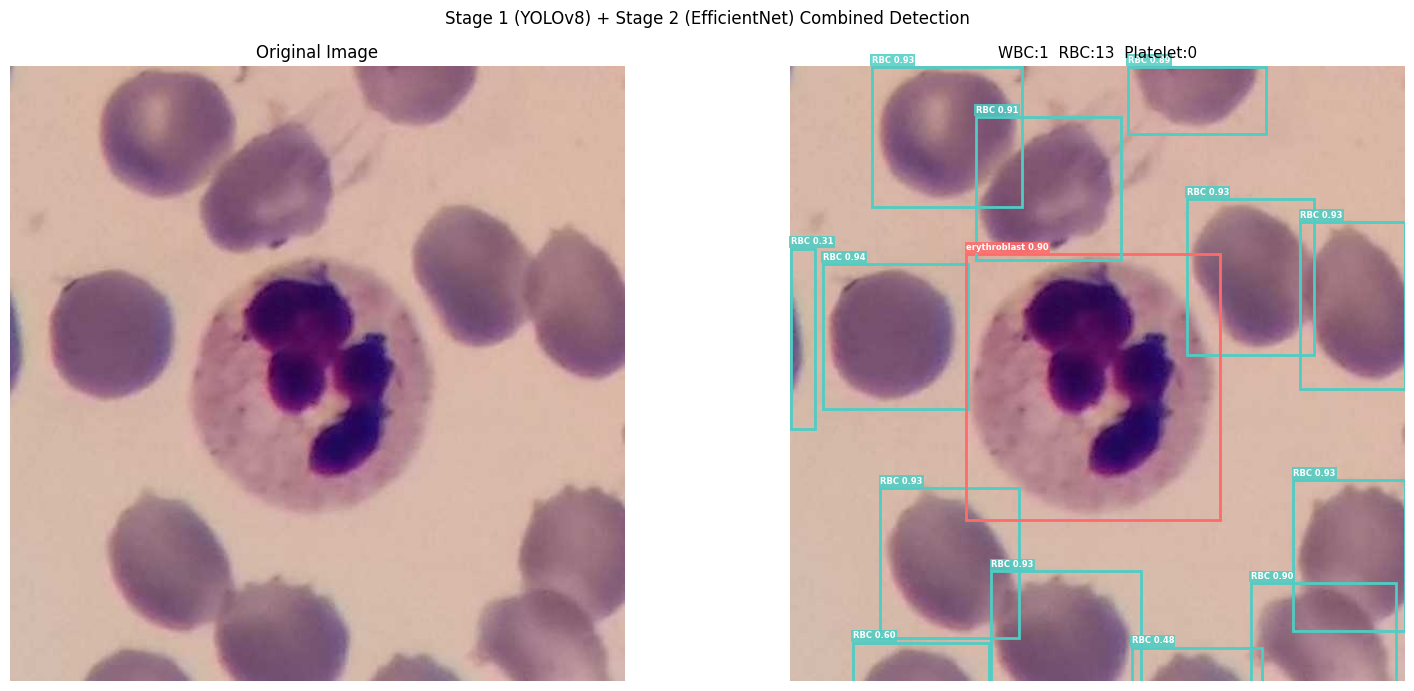

Saved -> figures/pipeline_output.png


In [ ]:
result = yolo_model.predict(test_image, conf=0.25,
                             verbose=False, device=0)[0]
img    = np.array(Image.open(test_image).convert('RGB'))
h, w   = img.shape[:2]
COLORS = {'WBC':'#FF6B6B', 'RBC':'#4ECDC4', 'Platelet':'#FFE66D'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(img)
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(img)
for box in result.boxes:
    cls_name = YOLO_CLASSES[int(box.cls[0])]
    conf_val = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    color = COLORS[cls_name]

    axes[1].add_patch(patches.Rectangle(
        (x1,y1), x2-x1, y2-y1,
        linewidth=2, edgecolor=color, facecolor='none'))

    if cls_name == 'WBC':
        crop = img[max(0,int(y1)-10):min(h,int(y2)+10),
                   max(0,int(x1)-10):min(w,int(x2)+10)]
        if crop.size > 0:
            subtype, sc = classify_wbc(
                crop, effnet_model, effnet_transform, device)
            label = f'{subtype} {sc:.2f}'
        else:
            label = 'WBC'
    else:
        label = f'{cls_name} {conf_val:.2f}'

    axes[1].text(x1, y1-4, label, color='white', fontsize=6,
                 fontweight='bold',
                 bbox=dict(facecolor=color, alpha=0.85,
                           pad=1, edgecolor='none'))

c = summary['cell_counts']
axes[1].set_title(
    f"WBC:{c['WBC']}  RBC:{c['RBC']}  Platelet:{c['Platelet']}",
    fontsize=11)
axes[1].axis('off')

plt.suptitle(
    'Stage 1 (YOLOv8) + Stage 2 (EfficientNet) Combined Detection',
    fontsize=12)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/pipeline_output.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved -> figures/pipeline_output.png')

# Evaluation Utilities (Retrieval + Generation + Mode Comparison)

In [ ]:
import csv
import json
import os
from datetime import datetime

def _parse_report_json(report_text):
    try:
        return json.loads(report_text), True
    except Exception:
        return {}, False

def evaluate_retrieval(retrieval_cases, k=5):
    """Compute a lightweight recall@k proxy and citation coverage."""
    if not retrieval_cases:
        raise ValueError('retrieval_cases is empty.')

    scores = []
    citation_hits = 0

    for case in retrieval_cases:
        query = case['query']
        expected_terms = [t.lower() for t in case.get('expected_terms', [])]
        retrieved_text = retrieve(query, n=k)
        lowered = retrieved_text.lower()

        hit_count = sum(1 for t in expected_terms if t in lowered)
        recall_proxy = (hit_count / len(expected_terms)) if expected_terms else 0.0
        has_citation = '[Reference' in retrieved_text
        citation_hits += int(has_citation)

        scores.append({
            'query': query,
            'expected_terms': expected_terms,
            'recall_at_k_proxy': round(recall_proxy, 4),
            'has_citation': has_citation,
        })

    summary = {
        'n_cases': len(scores),
        'mean_recall_at_k_proxy': round(sum(s['recall_at_k_proxy'] for s in scores) / len(scores), 4),
        'citation_coverage': round(citation_hits / len(scores), 4),
        'cases': scores,
    }
    return summary

def evaluate_generation(report_texts):
    """Compute schema-validity, citation-attached claim proxy, and uncertainty-trigger rate."""
    if not report_texts:
        raise ValueError('report_texts is empty.')

    required_keys = {
        'findings',
        'differential_diagnosis',
        'confidence_notes',
        'recommended_tests',
        'safety_flags',
        'citations',
    }

    valid_count = 0
    citation_claim_hits = 0
    uncertainty_hits = 0
    rows = []

    for text in report_texts:
        payload, is_json = _parse_report_json(text)
        has_schema = is_json and required_keys.issubset(set(payload.keys()))
        valid_count += int(has_schema)

        findings = payload.get('findings', []) if isinstance(payload, dict) else []
        citations = payload.get('citations', []) if isinstance(payload, dict) else []

        has_citation_claim = bool(findings) and bool(citations)
        citation_claim_hits += int(has_citation_claim)

        flags = payload.get('safety_flags', []) if isinstance(payload, dict) else []
        conf_notes = payload.get('confidence_notes', '') if isinstance(payload, dict) else ''
        uncertainty_trigger = (
            any(f in {'INSUFFICIENT_EVIDENCE', 'HIGH_UNCERTAINTY'} for f in flags)
            or ('uncertain' in str(conf_notes).lower())
            or ('low reliability' in str(conf_notes).lower())
        )
        uncertainty_hits += int(uncertainty_trigger)

        rows.append({
            'schema_valid': has_schema,
            'citation_attached_claim': has_citation_claim,
            'uncertainty_triggered': uncertainty_trigger,
        })

    n = len(report_texts)
    return {
        'n_reports': n,
        'schema_validity_rate': round(valid_count / n, 4),
        'citation_attached_claim_rate': round(citation_claim_hits / n, 4),
        'uncertainty_trigger_rate': round(uncertainty_hits / n, 4),
        'rows': rows,
    }

def _ask_gemini_baseline(json_summary):
    prompt = (
        'You are a clinical haematology assistant.\n'
        'Use ONLY this vision summary and provide concise clinical reasoning.\n'
        'If uncertain, say so clearly and avoid definitive diagnosis.\n\n'
        'Return JSON with keys: findings, differential_diagnosis, confidence_notes, '
        'recommended_tests, safety_flags, citations.\n'
        f'Vision summary: {json.dumps(json_summary)}'
    )
    response = client.models.generate_content(
        model='gemini-2.0-flash',
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.2)
    )
    return response.text.strip()

def _ask_gemini_with_rag_plain(json_summary, top_k=5):
    query = build_rag_query(json_summary)
    retrieved = retrieve(query, n=top_k)
    prompt = (
        'You are a clinical haematology assistant.\n'
        'Use retrieved evidence and vision summary for reasoning.\n'
        'If uncertain, say so clearly and avoid definitive diagnosis.\n\n'
        'Return JSON with keys: findings, differential_diagnosis, confidence_notes, '
        'recommended_tests, safety_flags, citations.\n'
        f'Vision summary: {json.dumps(json_summary)}\n'
        f'Retrieved evidence: {retrieved}'
    )
    response = client.models.generate_content(
        model='gemini-2.0-flash',
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.2)
    )
    return response.text.strip()

def compare_modes(json_summary, top_k=5):
    """Compare baseline LLM vs RAG vs RAG+uncertainty-aware prompt."""
    baseline_report = _ask_gemini_baseline(json_summary)
    rag_report = _ask_gemini_with_rag_plain(json_summary, top_k=top_k)
    rag_unc_report, _, _ = ask_gemini_with_rag(json_summary, top_k=top_k, return_json=True)

    reports = {
        'baseline_llm': baseline_report,
        'rag': rag_report,
        'rag_uncertainty_aware': rag_unc_report,
    }

    gen_eval = evaluate_generation(list(reports.values()))
    mode_rows = [
        {'mode': 'baseline_llm', 'report': baseline_report},
        {'mode': 'rag', 'report': rag_report},
        {'mode': 'rag_uncertainty_aware', 'report': rag_unc_report},
    ]

    out = {
        'generation_eval': gen_eval,
        'reports': reports,
        'mode_rows': mode_rows,
    }
    return out

def save_evaluation_results(eval_payload, out_dir='results'):
    os.makedirs(out_dir, exist_ok=True)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')

    json_path = os.path.join(out_dir, f'eval_summary_{ts}.json')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(eval_payload, f, indent=2)

    csv_path = os.path.join(out_dir, f'eval_modes_{ts}.csv')
    mode_rows = eval_payload.get('mode_rows', [])
    with open(csv_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(
            f,
            fieldnames=['mode', 'schema_valid', 'citation_attached_claim', 'uncertainty_triggered']
        )
        writer.writeheader()
        for row in mode_rows:
            parsed, ok = _parse_report_json(row['report'])
            writer.writerow({
                'mode': row['mode'],
                'schema_valid': ok,
                'citation_attached_claim': bool(parsed.get('findings')) and bool(parsed.get('citations')) if ok else False,
                'uncertainty_triggered': (
                    any(f in {'INSUFFICIENT_EVIDENCE', 'HIGH_UNCERTAINTY'} for f in parsed.get('safety_flags', []))
                    or ('uncertain' in str(parsed.get('confidence_notes', '')).lower())
                ) if ok else False,
            })

    return {'json_path': json_path, 'csv_path': csv_path}

In [ ]:
# Optional compact run block (safe to execute after summary is created)
retrieval_cases = [
    {
        'query': 'neutrophilia bacterial infection causes',
        'expected_terms': ['neutrophil', 'infection', 'bacterial'],
    },
    {
        'query': 'thrombocytopenia peripheral smear interpretation',
        'expected_terms': ['platelet', 'thrombocytopenia', 'smear'],
    },
]

retrieval_eval = evaluate_retrieval(retrieval_cases, k=5)
mode_comparison = compare_modes(summary, top_k=5)

evaluation_payload = {
    'retrieval_eval': retrieval_eval,
    'generation_eval': mode_comparison['generation_eval'],
    'mode_rows': mode_comparison['mode_rows'],
}

saved_paths = save_evaluation_results(evaluation_payload, out_dir='results')

print('Retrieval Eval:')
print(json.dumps(retrieval_eval, indent=2))
print('\nGeneration Eval:')
print(json.dumps(mode_comparison['generation_eval'], indent=2))
print('\nSaved evaluation artifacts:')
print(saved_paths)

# Reproducibility Metadata

In [ ]:
import sys
import platform
import importlib
from datetime import datetime, timezone

def _pkg_ver(name):
    try:
        return importlib.import_module(name).__version__
    except Exception:
        return 'not-installed'

meta = {
    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'python': sys.version.split()[0],
    'platform': platform.platform(),
    'device': str(torch.device('cuda' if torch.cuda.is_available() else 'cpu')),
    'packages': {
        'torch': _pkg_ver('torch'),
        'timm': _pkg_ver('timm'),
        'ultralytics': _pkg_ver('ultralytics'),
        'chromadb': _pkg_ver('chromadb'),
        'sentence_transformers': _pkg_ver('sentence_transformers'),
        'numpy': _pkg_ver('numpy'),
    },
}

os.makedirs('results', exist_ok=True)
with open('results/run_metadata_llm_rag.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

print(json.dumps(meta, indent=2))
print('Saved -> results/run_metadata_llm_rag.json')

# Final Pipeline Smoke Checks

In [ ]:
required_keys = {'cell_counts', 'total_cells', 'wbc_differential', 'uncertainty_summary'}

# Single-image and batch summary checks
summary_single = build_json_summary(test_image)
batch_images = [
    os.path.join(test_dir, f)
    for f in sorted(os.listdir(test_dir))
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
][:3]
summary_batch = build_json_summary(batch_images)

print('Required keys present:', required_keys.issubset(set(summary_single.keys())))
print('Single image_count:', summary_single.get('image_count'))
print('Batch image_count:', summary_batch.get('image_count'))
print('Batch cell_count_stats:', summary_batch.get('cell_count_stats'))

# RAG reasoning check
report_json, retrieved_text, rag_query = ask_gemini_with_rag(summary_single, top_k=5, return_json=True)
print('RAG query:', rag_query)
print('Report prefix:', report_json[:500])

# Evaluation utilities check
retrieval_cases = [
    {'query': 'neutrophilia bacterial infection causes', 'expected_terms': ['neutrophil', 'infection', 'bacterial']},
    {'query': 'thrombocytopenia peripheral smear interpretation', 'expected_terms': ['platelet', 'thrombocytopenia', 'smear']},
]
retrieval_eval = evaluate_retrieval(retrieval_cases, k=5)
mode_eval = compare_modes(summary_single, top_k=5)
payload = {
    'retrieval_eval': retrieval_eval,
    'generation_eval': mode_eval['generation_eval'],
    'mode_rows': mode_eval['mode_rows'],
}
saved = save_evaluation_results(payload, out_dir='results')
print('Saved evaluation artifacts:', saved)